<a href="https://colab.research.google.com/github/parsasafaie/ImagePRO/blob/main/trained_models/SignLanguage_MNIST_cnn_image_classifier/SignLanguage_MNIST_cnn_image_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p data
!wget -O data/sign_mnist_train.csv https://github.com/parsasafaie/ImagePRO/raw/refs/heads/main/trained_models/SignLanguage_MNIST_cnn_image_classifier/data/sign_mnist_train.csv
!wget -O data/sign_mnist_test.csv https://github.com/parsasafaie/ImagePRO/raw/refs/heads/main/trained_models/SignLanguage_MNIST_cnn_image_classifier/data/sign_mnist_test.csv

--2025-07-16 17:48:59--  https://github.com/parsasafaie/ImagePRO/raw/refs/heads/main/trained_models/SignLanguage_MNIST_cnn_image_classifier/data/sign_mnist_train.csv
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/parsasafaie/ImagePRO/refs/heads/main/trained_models/SignLanguage_MNIST_cnn_image_classifier/data/sign_mnist_train.csv [following]
--2025-07-16 17:49:00--  https://raw.githubusercontent.com/parsasafaie/ImagePRO/refs/heads/main/trained_models/SignLanguage_MNIST_cnn_image_classifier/data/sign_mnist_train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 83253609 (79M) [text/plain]
Savin

In [2]:
!pip install tensorflow
!pip install numpy
!pip install matplotlib
!pip install pandas

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers, models

In [4]:
train_df = pd.read_csv('data/sign_mnist_train.csv')
test_df = pd.read_csv('data/sign_mnist_test.csv')

In [5]:
x_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values

x_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

In [6]:
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

y_train = y_train.reshape(-1)

In [7]:
import string
all_letters = list(string.ascii_uppercase)
class_names = [letter for letter in all_letters if letter not in ['J', 'Z']]

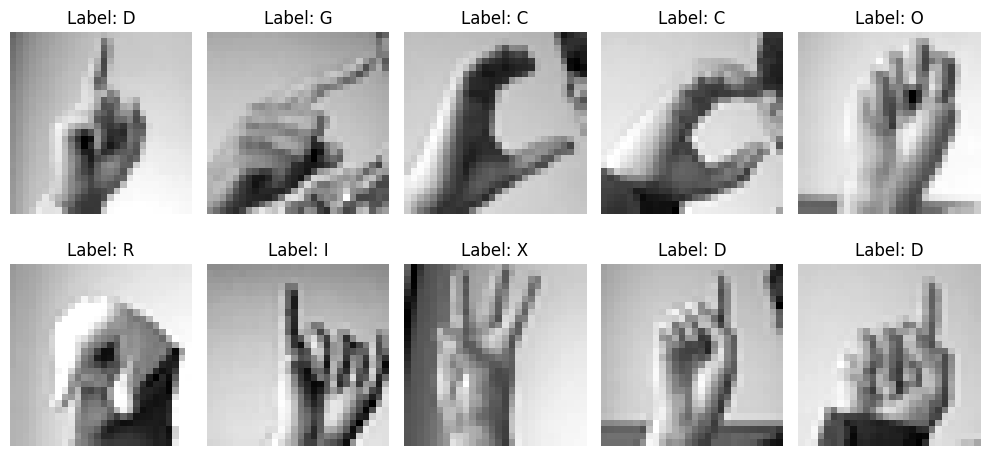

In [8]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {class_names[y_train[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
model = models.Sequential([
    layers.Input((28,28,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(25, activation='softmax')
])

In [10]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,969 (886.60 KB)

 Trainable params: 226,969 (886.60 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 42s 46ms/step - accuracy: 0.4944 - loss: 1.7457 - val_accuracy: 0.8339 - val_loss: 0.5504
Epoch 2/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 31s 35ms/step - accuracy: 0.9858 - loss: 0.0708 - val_accuracy: 0.8996 - val_loss: 0.4067
Epoch 3/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.9966 - loss: 0.0188 - val_accuracy: 0.8919 - val_loss: 0.5439
Epoch 4/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.9973 - loss: 0.0108 - val_accuracy: 0.9149 - val_loss: 0.4413
Epoch 5/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 1.0000 - loss: 7.6914e-04 - val_accuracy: 0.9126 - val_loss: 0.4818
Epoch 6/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.8625 - val_loss: 0.5250
Epoch 7/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 39s 37ms/step - accuracy: 0.9918 - loss: 0.0277 - val_accuracy: 0.9136 - val_loss: 0.4899
Epoch 8/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 1.0000 - loss: 3.752

In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")

225/225 - 2s - 9ms/step - accuracy: 0.9195 - loss: 0.5371

Test accuracy: 0.9195


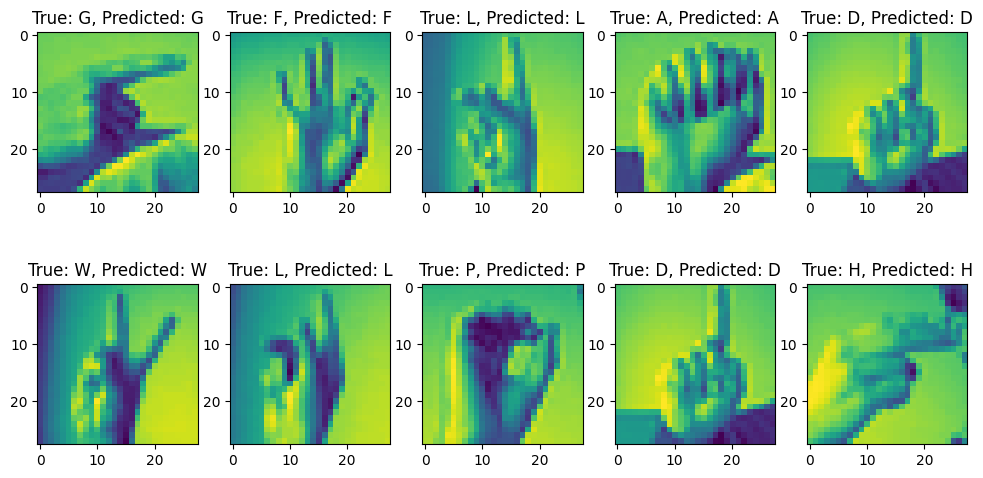

In [13]:
predicted_probs = model.predict(x_test[:10], verbose=0)
predicted_labels = tf.argmax(predicted_probs, axis=1)
plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i])
    plt.title(f"True: {class_names[y_test[i]]}, Predicted: {class_names[predicted_labels[i]]}")
plt.show()

In [ ]:
model.save('model.keras')